## Crop Recommendation Classifier using Keras
Building a Crop Recommendation Classifier with Keras involves creating a deep neural network that takes soil nutrients and environmental conditions as input and predicts the most suitable crop to grow. This notebook demonstrates how to train a crop recommendation classifier using a Keras Sequential model. The model uses a multi-class classification approach. Below are the process involves the following steps:

1.  **Loading and Preprocessing the Data**: The dataset is loaded from a CSV file. The features and target variables are separated. The categorical target labels are encoded into numerical values. The data is then split into training and testing sets.

2.  **Building the Keras Sequential Model**: A sequential model is constructed with multiple dense layers. The input layer is designed to accept the number of features in the dataset, and the output layer has a number of neurons equal to the number of unique crop labels, using a softmax activation function for multi-class classification.

3.  **Training the Model**: The model is compiled with an optimizer, a loss function suitable for multi-class classification (sparse categorical cross-entropy), and metrics to monitor during training (accuracy). The model is then trained on the training dataset.

4.  **Evaluating the Model**: The trained model is evaluated on the test dataset to assess its performance. The accuracy of the model on unseen data is a key metric for evaluation.

5.  **Converting the Model to C Code**: The trained Keras model is converted into C code using the `emlearn` library. This allows the model to be deployed on embedded systems and microcontrollers for real-world applications. The C code includes the model weights and the necessary functions to perform inference.

## Importing Dataset
Crop recommendation is a CSV-based dataset are collections of agricultural, environmental, and soil metrics used to train machine learning models for predicting optimal crops. These datasets empower farmers and smart farming algorithms to make data-driven decisions based on specific soil and climate conditions to optimize agricultural yield by predicting suitable crops. It include the following agricultural and environmental parameters:
* **Soil Nutrients**: Nitrogen (N), Phosphorus (P), and Potassium (K) content.
* **Environmental Factors**: Average temperature, humidity levels, and rainfall amounts.
* **Soil Properties**: pH levels
* **Target Variable**: Recommended crops (e.g., rice, wheat, maize, cotton, coffee, etc.).

In [5]:
# Import pandas API
import pandas as pd

# Read the input csv file
dataset = pd.read_csv('crop_recommendation.csv')

# Display 10 random samples from the dataset
dataset.sample(10).style.hide(axis='index') 

N,P,K,temperature,humidity,ph,rainfall,label
31,35,23,30.302605,47.182836,7.707595,68.040398,mothbeans
84,40,42,26.283057,73.357635,6.704274,186.689828,jute
38,141,198,13.058097,80.282980,5.757010,70.756336,grapes
61,68,50,35.214628,91.497251,6.793245,243.074507,papaya
86,36,24,26.549864,72.891873,5.787268,73.336361,maize
32,14,37,22.730313,88.485679,6.825256,104.684324,pomegranate
27,65,18,20.109938,23.223238,5.595032,73.363865,kidneybeans
54,77,85,17.141861,17.066243,7.829211,83.746067,chickpea
10,37,22,28.727527,89.127604,7.069748,58.529743,mungbean
121,53,19,23.513087,76.726214,7.976889,80.112721,cotton


In [8]:
# Create a data frame of the dataset shape
dataset_shape = pd.DataFrame({
    'Samples': [dataset.shape[0]],
    'Features': [dataset.shape[1] - 1],
    'Classes (Crops)': [dataset['label'].nunique()]
})

# Display the dataset shape
dataset_shape.style.hide(axis='index')

Samples,Features,Classes (Crops)
2200,7,22


## Assigning Features and Target Variables from the Dataset
* **Features** also known as *predictors* are individual independent variables that act as input data in the classifier model.
* **Targets** are the final output data trying to predict.

In [9]:
# Assigned data variables as features
X = dataset.drop("label", axis=1)

# Assigned label variables as targets
y = dataset["label"]

# Display 10 random features dataframe
X.sample(10).style.hide(axis='index') 

N,P,K,temperature,humidity,ph,rainfall
22,11,29,28.033806,95.016306,5.955743,218.005571
120,20,45,25.665760,88.698423,6.114129,54.227225
6,64,23,23.335652,67.404607,7.065264,36.186787
61,41,35,24.971787,79.475579,6.842966,195.757162
28,7,9,34.591785,92.132298,6.730758,115.565029
2,21,44,18.921572,87.312903,6.568934,102.801327
26,35,31,33.446199,53.059805,5.339557,98.050894
85,35,32,26.249282,54.286178,6.854011,133.112023
60,68,83,19.120652,18.434758,6.620901,85.529502
95,16,55,25.269312,87.550551,6.612848,40.126504


In [57]:
# Display 10 random targets dataframe
y.sample(10)

588      mothbeans
504      mothbeans
1795        papaya
603       mungbean
427     pigeonpeas
1543         apple
1207        grapes
138          maize
557      mothbeans
1510         apple
Name: label, dtype: str

# Visualizing Features
**Class features visualization** using **scatter plots** is a foundational technique in exploratory data analysis (EDA) and machine learning, used to understand the relationship between numerical features, identify data clusters, and detect outliers. In classification problems, scatter plots are particularly useful for visualizing the separation between different classes by mapping class labels to colors or shapes.

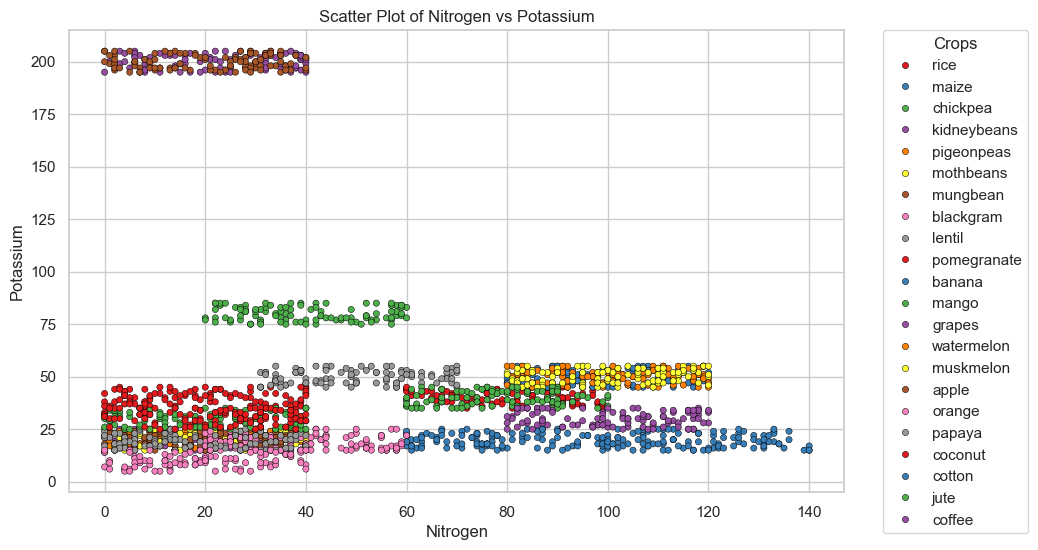

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define figure size for the plot
plt.figure(figsize=(10, 6), dpi=100)

# Create a scatter plot of the two features 'Nitogen' (N) and 'Potassium' (K)
sns.scatterplot(data=dataset, x='N', y='K', hue='label', palette='Set1', edgecolor='black', s=20)

# Show the plot
plt.title('Scatter Plot of Nitrogen vs Potassium')
plt.xlabel('Nitrogen')
plt.ylabel('Potassium')
plt.legend(title='Crops', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

**Box and whisker plots** (box plots) are powerful visualization tools for analyzing class features (attributes) by displaying the distribution, central tendency, spread, and skewness of numerical data. They are particularly effective for comparing characteristics across multiple categories, such as comparing test scores between classes or analyzing features within a dataset.

<img src="https://help.ezbiocloud.net/wp-content/uploads/2020/04/%E1%84%89%E1%85%B3%E1%84%8F%E1%85%B3%E1%84%85%E1%85%B5%E1%86%AB%E1%84%89%E1%85%A3%E1%86%BA-2020-04-19-%E1%84%8B%E1%85%A9%E1%84%8C%E1%85%A5%E1%86%AB-9.41.35.png" style="width:70%; height:auto; display: block; margin-left: auto; margin-right: auto;">

**Key Components Visualized**
* **Median (Q2)**: The middle value of the data, indicated by a line inside the box.
* **Interquartile Range (IQR)**: The box, representing the middle 50% of data (Q1 to Q3).
* **Whiskers**: Lines extending to the minimum and maximum non-outlier values, showing the range of data.
* **Outliers**: Individual dots beyond the whiskers, highlighting unusual observations.

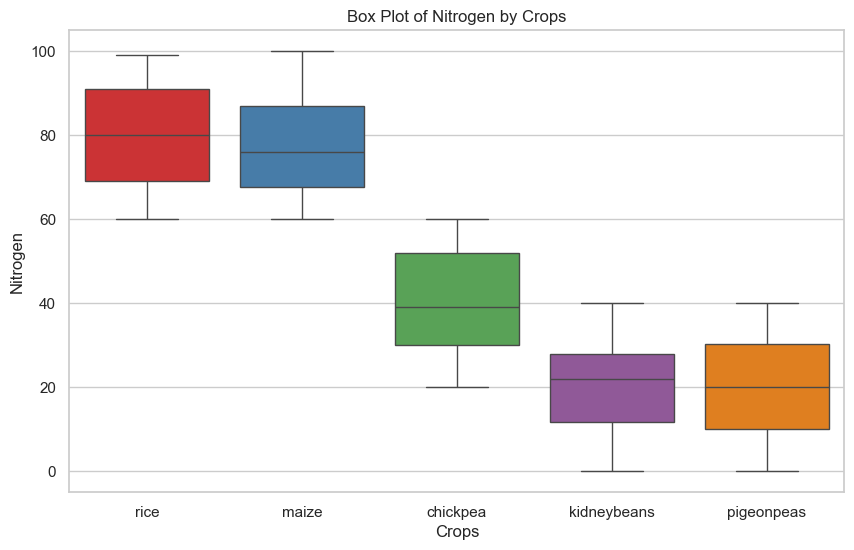

In [62]:
# Create a box and whisker plot to visualize the distribution of 'Nitrogen (N)' for different crops
sample_crops = dataset['label'].unique()[:5]            # Select the first five unique crops
sample = dataset[dataset['label'].isin(sample_crops)]   # Filter the dataset to include only the selected crops

# Define figure size for the plot
plt.figure(figsize=(10, 6), dpi=100)

# Create a box plot of 'Nitrogen (N)' for the selected crops
sns.boxplot(x='label', y='N', data=sample, palette='Set1', hue='label')
plt.title('Box Plot of Nitrogen by Crops')
plt.xlabel('Crops')
plt.ylabel('Nitrogen')
plt.show()

**Violin plots** are powerful data visualization tools used to compare the distribution, density, and variability of numerical features across different classes or categories. They are superior to box plots when data is multimodal (has multiple peaks) or skewed, as they display the full probability density of the data.

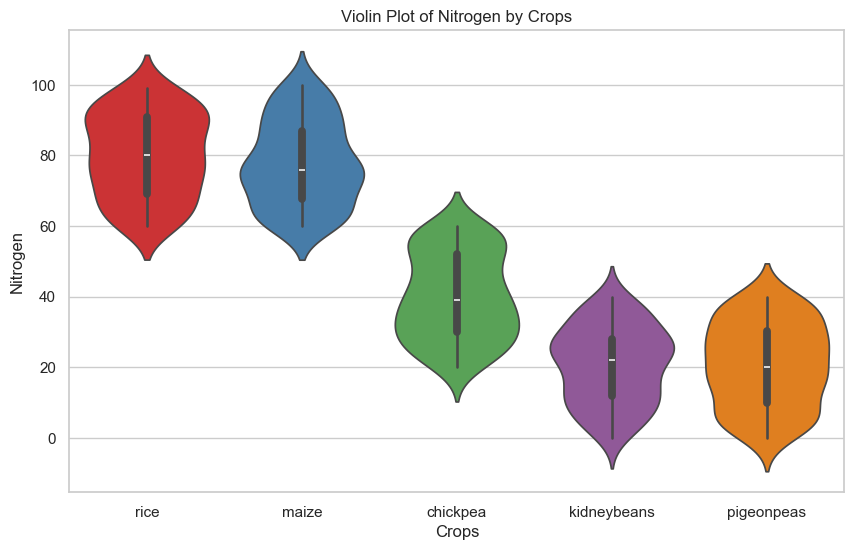

In [60]:
# Define figure size for the plot
plt.figure(figsize=(10, 6), dpi=100)

# Create a Violin Plot to visualize the distribution of 'Nitrogen (N)' for each crop
sns.violinplot(x='label', y='N', data=sample, palette='Set1', hue='label')
plt.title('Violin Plot of Nitrogen by Crops')
plt.xlabel('Crops')
plt.ylabel('Nitrogen')
plt.show()

**Density plots** also known as *Kernel Density Estimation plots* are a powerful visualization tool used to show the probability density function of a continuous, numerical variable. They act as a smoothed version of a histogram, making them ideal for identifying patterns such as skewness, modality (peaks), and clusters across different classes in a dataset.

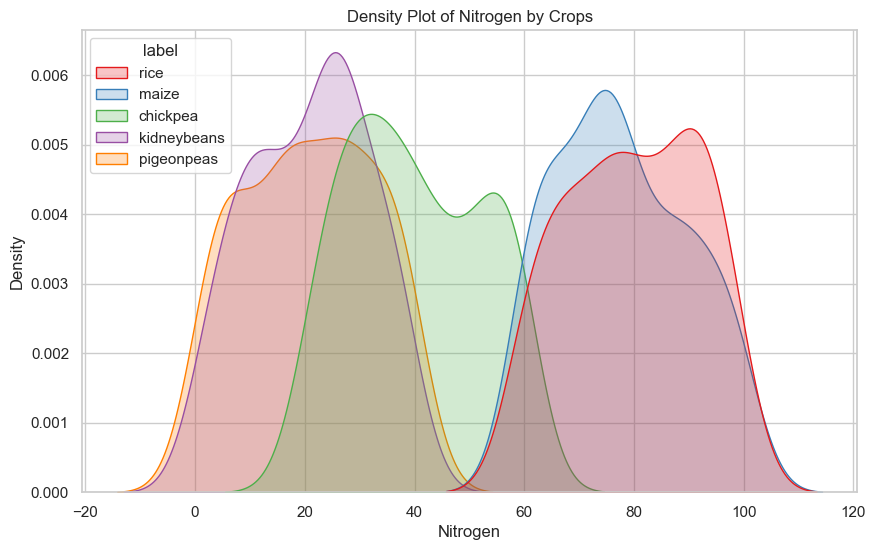

In [61]:
# Define figure size for the plot
plt.figure(figsize=(10, 6), dpi=100)

# Create a Density Plot to visualize the distribution of "Nitrogen (N)" for different crops
sns.kdeplot(data=sample, x='N', hue='label', fill=True, palette='Set1')
plt.title('Density Plot of Nitrogen by Crops')
plt.xlabel('Nitrogen')
plt.ylabel('Density')
plt.show()

## One-Hot Encoding
**One-hot encoding** is a process of converting categorical data variables to be provided to machine learning algorithms to improve predictions. One-hot encoding is a method of representing categorical variables as binary vectors. In this notebook, the crop target classes are encoded using one-hot encoding. Each crop label is represented by a binary vector where one bit is hot (set to 1) and all others are cold (set to 0).

### Sample Format of One-Hot Encoded Targets

If you have 3 classes (e.g., `'Apple'`, `'Banana'`, `'Blackgram'`, ...), they would be encoded as follows:
- `'Apple'` -> `[1, 0, 0, ..., 0]`
- `'Banana'` -> `[0, 1, 0, ..., 0]`
- `'Blackgram'` -> `[0, 0, 1, ..., 0]`

This allows the model to process the categorical data without assuming any ordinal relationship between the categories.


In [53]:
# Import OneHotEncoder from sklearn
from sklearn.preprocessing import OneHotEncoder

# Create an instance of OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the target labels using OneHotEncoder
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

# Create column names for one-hot encoded targets (no underscore in column names)
target_labels = encoder.get_feature_names_out([''])

# Use list comprehension with str.removeprefix()
target_labels = [s.removeprefix('_').capitalize() for s in target_labels]

# Convert encoded target to a data frame
y_encoded_df = pd.DataFrame(y_encoded.astype(int), columns=target_labels)

# Display 10 random samples of the encoded targets data frame
y_encoded_df.sample(10).style

,Apple,Banana,Blackgram,Chickpea,Coconut,Coffee,Cotton,Grapes,Jute,Kidneybeans,Lentil,Maize,Mango,Mothbeans,Mungbean,Muskmelon,Orange,Papaya,Pigeonpeas,Pomegranate,Rice,Watermelon
1504,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
114,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
811,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1236,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
229,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2176,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
141,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1822,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1890,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


# Dataset Preprocessing
### Normalizing the Features Data
Normalizing feature data (scaling to a 0-1 range or standardizing to mean=0, std=1) before fitting a regression model is crucial when features have vastly different scales. It prevents features with larger magnitudes from dominating, speeds up gradient descent convergence, and ensures regularization treats all features equally.

In this example, we will use `MinMaxScaler` to normalize the features to a range from `0` to `1` to prevent features with larger magnitudes from dominating the model.

For a given data point $X$, the Min-Max scaled value $X_{scaled}$ is calculated as: 
$$
X_{scaled}=\frac{X-X_{min}}{X_{max}-X_{min}}
$$

In [64]:
# Import MaxAbsScaler from sklearn
from sklearn.preprocessing import MinMaxScaler

# Create an instance of MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the features using MinMaxScaler
X_scaled = scaler.fit_transform(X)

# Convert scaled features to a data frame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display 10 random samples of the scaled features data frame
X_scaled_df.sample(10).style.hide(axis='index')

N,P,K,temperature,humidity,ph,rainfall
0.700000,0.142857,0.235000,0.472153,0.803696,0.422888,0.104485
0.157143,0.914286,0.980000,0.430254,0.768329,0.388509,0.169078
0.592857,0.035714,0.240000,0.462105,0.825325,0.418390,0.102560
0.735714,0.328571,0.075000,0.401048,0.815277,0.550804,0.256612
0.650000,0.221429,0.200000,0.448145,0.795535,0.380368,0.890124
0.192857,0.407143,0.095000,0.568278,0.612582,0.598588,0.151114
0.264286,0.864286,0.955000,0.423942,0.894943,0.325286,0.312419
0.664286,0.121429,0.235000,0.509665,0.782368,0.533096,0.077831
0.171429,0.235714,0.085000,0.449158,0.516293,0.730592,0.053020
0.142857,0.164286,0.105000,0.503707,0.901042,0.317688,0.527524


#### Preprocessing: Export Scaler Parameters for Arduino
After fitting StandardScaler on the training features, the learned mean and standard deviation values must be exported so the microcontroller can apply the same normalization during inference.

The ```emlearn cgen``` utility is used to convert these parameters into C++ constant arrays, typically named scaler_means and scaler_stds. These arrays are then included in the Arduino project to keep preprocessing consistent between Python training and embedded deployment.

This step prevents feature mismatch and helps maintain model accuracy when running the classifier on-device.

In [113]:
# Scaler parameters for each feature column to be used in the Arduino implementation
scaler_params = {
    'min': scaler.data_min_.tolist(),
    'max': scaler.data_max_.tolist(),
}

# Convert scaler parameters to Arduino C++ arrays using emlearn.cgen
from emlearn import cgen
import textwrap

# Get the number of features for array declaration
feature_count = len(X.columns)
linewrap = 100

# Declare scaler min and max parameters as constant arrays in C++
min_array_c = cgen.array_declare(
    "scaler_min",
    feature_count,
    dtype="float",
    modifiers="const",
    values=scaler_params['min']
)

max_array_c = cgen.array_declare(
    "scaler_max:",
    feature_count,
    dtype="float",
    modifiers="const",
    values=scaler_params['max']
)

# Wrap lines like the reference script
features_size_wrapped = "\n".join(textwrap.wrap(f"static constexpr int n_features =  {feature_count};", linewrap))
min_array_wrapped = "\n".join(textwrap.wrap(min_array_c, linewrap))
max_array_wrapped = "\n".join(textwrap.wrap(max_array_c, linewrap))

# Combine all the wrapped code into a single string for the scaler header file
scaler_header_code = (
    features_size_wrapped + "\n\n"
    + min_array_wrapped + "\n\n"
    + max_array_wrapped + "\n\n"
)

# Print the scaler code snippet for Arduino implementation
print("/******* Scaler Parameters for Arduino C++ Implementation: *******/\n")
print(scaler_header_code)

/******* Scaler Parameters for Arduino C++ Implementation: *******/

static constexpr int n_features =  7;

const float scaler_min[7] = { 0.000000f, 5.000000f, 5.000000f, 8.825675f, 14.258040f, 3.504752f,
20.211267f };

const float scaler_max:[7] = { 140.000000f, 145.000000f, 205.000000f, 43.675493f, 99.981876f,
9.935091f, 298.560117f };




# Splitting the Dataset into Training, Testing, and Validation Set
Splitting a dataset is a crucial step in machine learning to evaluate model performance and prevent overfitting. Typically, the data is divided into three sets:
- **Training Set**: Used to train the model.
- **Validation Set**: Used to tune hyperparameters and select the best model.
- **Testing Set**: Used to assess the final model performance.

A common approach is to first split the data into training and testing sets, then further split the training set into training and validation sets. This ensures that the validation and test sets remain unseen during training and hyperparameter tuning.

<img src="https://cdn.imweb.me/upload/S202105076e626e4618b27/0f0c2df8f341c.png" style="width:70%; height:auto;">

In [66]:
# Include Train test set split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split data set to training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, 
                                                    y_encoded, 
                                                    test_size=0.20, 
                                                    shuffle=True, 
                                                    random_state=43, 
                                                    stratify=y_encoded)

# Split the training set for validation (20% of training set) and training (80% of training set)
X_null, X_val, y_null, y_val = train_test_split(X_train, 
                                                y_train,
                                                test_size=0.20,
                                                shuffle=True,
                                                random_state=43,
                                                stratify=y_train)

# Create a dataframe that holds the dataset shape (number of samples and features) for training and testing sets
dataset_shape = pd.DataFrame({
    'Dataset': ['Dataset', 'Training Set', 'Testing Set', 'Validation Set'],
    'Samples': [X_scaled.shape[0], X_train.shape[0], X_test.shape[0], X_val.shape[0]],
    'Features': [X_scaled.shape[1], X_train.shape[1], X_test.shape[1], X_val.shape[1]],
    'Target Classes': [y_encoded.shape[1], y_train.shape[1], y_test.shape[1], y_val.shape[1]]
})

# Display the training and test set shapes
dataset_shape.style.hide(axis='index')

Dataset,Samples,Features,Target Classes
Dataset,2200,7,22
Training Set,1760,7,22
Testing Set,440,7,22
Validation Set,352,7,22


## Train a Neural Network Classifier Model Using Keras
Keras is a high-level neural networks API, written in Python and capable of running on top of TensorFlow. It was developed with a focus on enabling fast experimentation. Make sure you have the necessary libraries installed to proceed with training the model.

### Installation

To install Keras, you can use `pip`. It is recommended to install it in a virtual environment.

```bash
pip install keras
pip install tensorflow
```

We will train a neural network classifier on the crops recommendation dataset. Neural networks are powerful models capable of capturing complex patterns in data by learning multiple layers of representations.

We will use Keras's `Sequential` to build and train the model. The training process involves:
- Initializing the DNN with a specific architecture (number of layers and neurons) and hyperparameters.
- Fitting the model to the training data.
- Monitoring the loss curve to ensure proper convergence.
- Evaluating the model's performance on validation and test sets.

This approach helps us understand how neural networks can be applied to classic classification problems.


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input

# Create a sequential model with an explicit Input layer
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Input Layer with shape equal to the number of features
    Dense(64, activation='relu'),      # First hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),      # Second hidden layer with 32 neurons and ReLU activation
    Dense(y_train.shape[1],            # Output layer with shape equal to the number of target classes
          activation='softmax')        # and softmax activation function for multiclass classification
])

# Compile the model with Adam optimizer, categorical crossentropy loss function, and accuracy metric
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with training data, validation data, 50 epochs, and batch size of 32
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1210 - loss: 3.0519 - val_accuracy: 0.1449 - val_loss: 2.9787
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1778 - loss: 2.8776 - val_accuracy: 0.1847 - val_loss: 2.7234
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2784 - loss: 2.5271 - val_accuracy: 0.4176 - val_loss: 2.2822
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4966 - loss: 2.0556 - val_accuracy: 0.5511 - val_loss: 1.8019
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6335 - loss: 1.6072 - val_accuracy: 0.6903 - val_loss: 1.4034
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7136 - loss: 1.2604 - val_accuracy: 0.8011 - val_loss: 1.1151
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7665 - loss: 1.0238 - val_accuracy: 0.8040 - val_loss: 0.9272
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8153 - loss: 0.8554 - val_accuracy: 0.8608 - val_loss:

# Visualization of Keras Neural Network Training Process
Visualize Keras loss curves by plotting the `history.history` dictionary returned by `model.fit()` using Matplotlib. Key metrics to plot include training loss (`'loss'`) and validation loss (`'val_loss'`) against epochs to identify overfitting or underfitting. Visualizing the loss curve during training helps us understand how well the neural network is learning. The loss curve shows the value of the loss function after each iteration of training. A steadily decreasing loss indicates that the model is learning and converging. After training a Keras model, use the history object to plot the learning curve. 

By plotting the learning curve, we can:
- Monitor the training process and detect issues like poor convergence or overfitting.
- Decide if more training epochs are needed or if early stopping should be applied.
- Compare the effect of different hyperparameters on the learning process.
- How well the model is learning from the data
- Whether the model is overfitting or underfitting
- If more data could improve performance

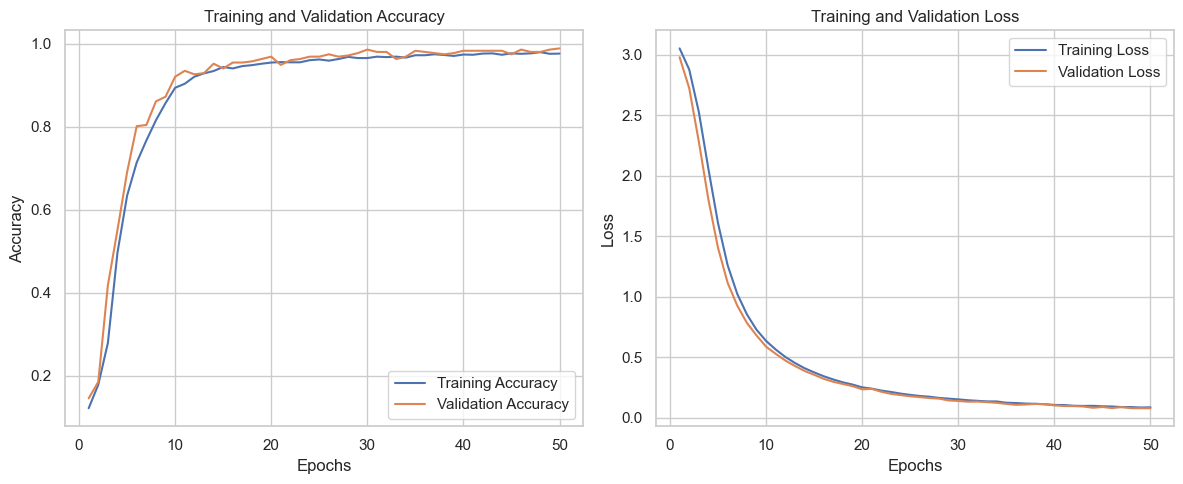

In [73]:
# Compute for the training and validation accuracy from the training history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Compute for the training and validation loss from the training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# return epochs range for plotting
epochs_range = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5), dpi=100)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
# Evaluate the model on the training and test sets
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

# Create a dataframe to display the evaluation results
evaluation_results = pd.DataFrame({
    'Dataset': ['Training Set', 'Validation Set'],
    'Loss': [f'{train_loss:.4f}', f'{val_loss:.4f}'],
    'Accuracy': [f'{train_accuracy * 100.00:.2f}%', f'{val_accuracy * 100.00:.2f}%']
})

# Display the evaluation results
evaluation_results.style.hide(axis='index')

Dataset,Loss,Accuracy
Training Set,0.0790,98.30%
Validation Set,0.0791,98.86%


## K-Fold Cross Validation
**K-Fold Cross Validation** is a technique for evaluating the performance and generalization ability of a machine learning model. It works by splitting the dataset into K equally sized folds. The model is trained on K-1 folds and tested on the remaining fold, repeating this process K times so each fold serves as the test set once.

Benefits of K-Fold Cross Validation:
- Provides a more reliable estimate of model performance compared to a single train/test split.
- Reduces variance and bias in evaluation.
- Helps detect overfitting and underfitting.

In this notebook, we use K-Fold Cross Validation to assess the accuracy and stability of the neural network classifier.
<img src="https://www.googleapis.com/download/storage/v1/b/kaggle-forum-message-attachments/o/inbox%2F3098088%2F749c3d1b927040bd84da7fdd18c8d4dc%2F5-fold-cross-validation_SIMPLE-EXAMPLE_v2.png?generation=1722449218394340&alt=media" style="width:70%; height:auto;">

In [85]:
# K-fold cross validation with 5 folds
from sklearn.model_selection import KFold

# Number of folds for training dataset spliting
n_folds = 5

# Define KFold cross-validator with the specified number of folds, shuffling, and random state for reproducibility
kfold = KFold(n_splits=n_folds, shuffle=True, random_state=43)

# Lists to store the accuracy and loss for each fold
nth_fold_accuracies = []
nth_fold_losses = []

# Perform K-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), start=0):
    print(f"Training fold {fold + 1}/{n_folds}...")
    
    # Split the training data into the current fold's training and validation sets
    X_train_fold, y_train_fold = X_train[train_idx], y_train[train_idx]
    X_val_fold, y_val_fold = X_train[val_idx], y_train[val_idx]
    
    # Create a new instance of the model for each fold
    model_fold = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(y_train.shape[1], activation='softmax')
    ])
    
    # Compile the model
    model_fold.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model on the current fold's training data and validate on the current fold's validation data
    history_fold = model_fold.fit(X_train_fold, y_train_fold, epochs=50, batch_size=32, validation_data=(X_val_fold, y_val_fold), verbose=0)
    
    # Evaluate performance on the validation slice
    score = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    
    # Print the validation accuracy and loss for the current fold
    print(f"Fold {fold + 1} - Validation Accuracy: {score[1]:.4f}, Validation Loss: {score[0]:.4f}")
    
    # Append the accuracy and loss for the current fold to the respective lists
    nth_fold_accuracies.append(score[1])
    nth_fold_losses.append(score[0])

# Print the overall accuracy and loss across all folds
print("\n--- Cross-Validation Results ---")
print(f"Average Validation Accuracy: {sum(nth_fold_accuracies) / n_folds:.4f}")
print(f"Average Validation Loss: {sum(nth_fold_losses) / n_folds:.4f}")

Training fold 1/5...
Fold 1 - Validation Accuracy: 0.9773, Validation Loss: 0.1290
Training fold 2/5...
Fold 2 - Validation Accuracy: 0.9744, Validation Loss: 0.1186
Training fold 3/5...
Fold 3 - Validation Accuracy: 0.9631, Validation Loss: 0.1259
Training fold 4/5...
Fold 4 - Validation Accuracy: 0.9460, Validation Loss: 0.1536
Training fold 5/5...
Fold 5 - Validation Accuracy: 0.9773, Validation Loss: 0.1041

--- Cross-Validation Results ---
Average Validation Accuracy: 0.9676
Average Validation Loss: 0.1262


## Evaluating the Performance of the Classifier Model
**Classification metrics** evaluate the performance of machine learning models that categorize data into distinct classes. Key metrics include accuracy (overall correctness), precision (correct positive predictions), recall/sensitivity (finding all positive samples), and the F1-score (harmonic mean of precision and recall). The choice of metric depends on class balance.

### Key Classification Metrics:
* **Accuracy**: Percentage of correct predictions out of all predictions. It is best for balanced datasets.
* **Precision**: Proportion of true positive predictions among all positive predictions. Use this when the cost of false positives is high.
* **Recall** (Sensitivity): Proportion of true positive predictions among all actual positive instances. 
* **F1-Score**: The harmonic mean of precision and recall, balancing both measures. Ideal for imbalanced data.

### Performance of the Keras Classifier Model
Keras classifier performance is evaluated by compiling models with metrics like accuracy, training with `model.fit()`, and evaluating on test data. Evaluating a neural network model using a test set provides an unbiased estimate of how well the model generalizes to new, unseen data. This step is the "gold standard" of model assessment and must only be performed after the model has been completely trained and its hyperparameters tuned.

In [86]:
# Print the performance metrics such as accuracy, precision, recall, and F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Perform prediction on the test set
predictions = model.predict(X_test)

# Convert one-hot encoded true labels and predicted probabilities to class indices
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(predictions)

# Create a dataframe to display the true labels and predicted labels
results_df = pd.DataFrame({
    'True Label': y_test_labels.flatten(),  
    'Predicted Label': y_pred_labels.flatten()
})

# Display 10 random samples of the true labels and predicted labels
results_df.sample(10).style.hide(axis='index')

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


True Label,Predicted Label
lentil,lentil
kidneybeans,kidneybeans
coconut,coconut
rice,rice
muskmelon,muskmelon
banana,banana
coconut,coconut
banana,banana
rice,rice
blackgram,blackgram


In [88]:
# Create a dataframe for the model performance metrics
performance_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f'{accuracy_score(y_test_labels, y_pred_labels) * 100.00:.2f}%',
              f'{precision_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%',
              f'{recall_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%',
              f'{f1_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%']
})

# Display the performance metrics
performance_metrics.style.hide(axis='index')

Metric,Score
Accuracy,97.95%
Precision,98.03%
Recall,97.95%
F1 Score,97.96%


## Confusion Matrix
A **confusion matrix** is a useful tool for evaluating the performance of a classification model. It provides a summary of prediction results on a classification problem, showing the number of correct and incorrect predictions broken down by each class.

**Key Points:**
- Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.
- The diagonal elements represent the number of points for which the predicted label is equal to the true label (correct predictions).
- Off-diagonal elements are those that are mislabeled by the classifier.

**Why use a confusion matrix?**
- To visualize the performance of a classification algorithm.
- To identify types of errors made by the model (e.g., which classes are most often confused).
- To compute important metrics such as accuracy, precision, recall, and F1-score.

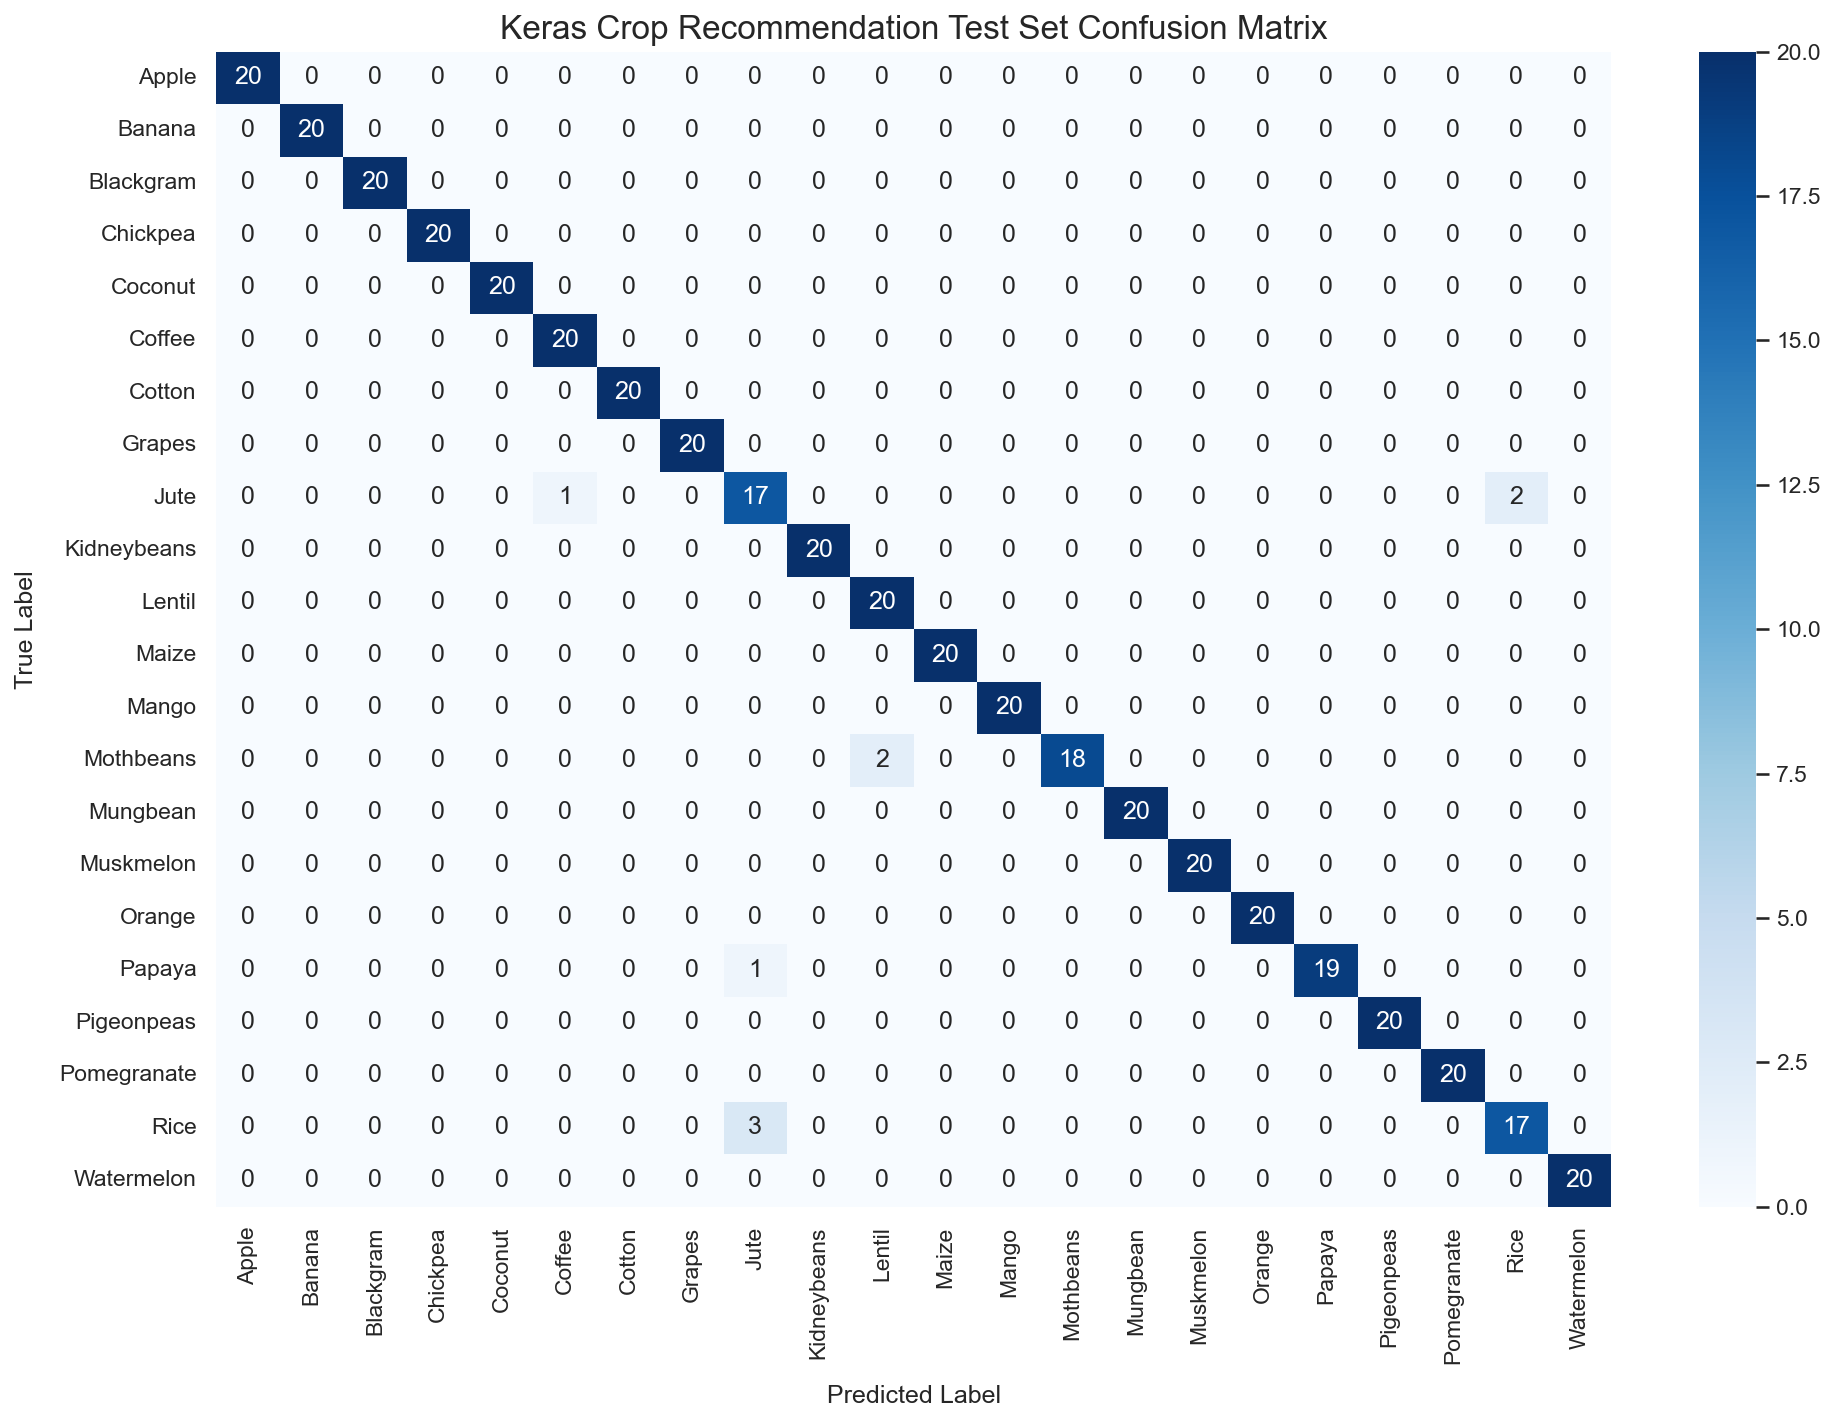

In [ ]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for the test set
cm_test = confusion_matrix(y_test_labels, y_pred_labels)

# Plot the confusion matrix using seaborn heatmap
fig, ax = plt.subplots(figsize=(15, 10), dpi=150)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=target_labels, yticklabels=target_labels)
plt.title('Keras Crop Recommendation Test Set Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.show()

## Select Random Test Samples for Prediction
Below, we select a random sample from the test set and use the trained model to predict its class. The predicted class and the true class are compared to assess the model's performance on individual samples

In [ ]:
# Generate a random number ranges from the test set for inference
import numpy as np
random_index = np.random.randint(0, X_test.shape[0])

# Get random test sample features
X_test_sample = X_test[random_index:random_index+1]
y_test_label = y_test[random_index:random_index+1]

# Create a dataframe to hold the raw input features (before scaling), the scaled input features, and the true label
inference_df = pd.DataFrame({
    'Raw Features': [pd.DataFrame(scaler.inverse_transform(X_test_sample.astype('float32'))).to_csv(header=False, index=False).strip()],
    'Scaled Features': [pd.DataFrame(X_test_sample).to_csv(header=False, index=False).strip()],
    'True Class': [encoder.inverse_transform(y_test_label)[0][0].capitalize()]
})

# Limit the scaled features dataframe decimal places to 6 for better readability
inference_df['Scaled Features'] = inference_df['Scaled Features'].apply(lambda x: 
                                                                    '\n'.join([','.join([f'{float(value):.6f}' 
                                                                        for value in row.split(',')]) 
                                                                            for row in x.split('\n')]))

# Display the inference dataframe
inference_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}) 

Raw Features,Scaled Features,True Label
"39.0,7.0,29.0,27.542732,94.59086,6.362544,150.2012","0.278571,0.014286,0.120000,0.537078,0.937112,0.444423,0.467004",Coconut


## Make a Prediction
To make predictions with a Keras neural network model using random samples, use the ```model.predict()``` function on a NumPy array of a random test sample.

In [124]:
# Print the prediction
predicted_class = model.predict(X_test_sample)

# Compute for the prediction scores for each class
y_pred_loss, y_pred_accuracy = model.evaluate(X_test_sample, y_test_label, verbose=0)

# Compute for the index of the predicted class with the highest probability
predicted_class_index = np.argmax(predicted_class)

# Create a dataframe to display the predicted class
predicted_class_df = pd.DataFrame({
    'Predicted Class': [encoder.inverse_transform(predicted_class)[0][0].capitalize()],
    'Loss': [f'{y_pred_loss:.4f}'],
    'Probability': [f'{predicted_class[0, predicted_class_index] * 100.00:.2f}%']
})

# Display the predicted class dataframe
predicted_class_df.style.hide(axis='index')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


Predicted Class,Loss,Probability
Coconut,0.0053,99.47%


## Port the Classifier Model to C Code
### emlearn - Machine Learning for Tiny Embedded Systems
```emlearn``` is an open-source Python library that allows converting scikit-learn and Keras models to efficient C code. This makes it easy to deploy to any microcontroller with, while keeping Python-based workflow that is familiar to Machine Learning Engineers.

To install emlearn to convert models in Python, use 
```bash 
pip install emlearn
```

In [106]:
# Convert model using emlearn
import emlearn

# Convert the trained Neural Network model to C++ code using emlearn
sequencial_model_cgen = emlearn.convert(model, method='inline', dtype='int', return_type='classifier')

# Generate and save the C code to a header file
sequencial_model_c_code = sequencial_model_cgen.save(file='NeuralNetworkClassifier.h', name='NeuralNetworkClassifier')

# Display the model generated C code
print(sequencial_model_c_code)


#include <eml_net.h>
static const float NeuralNetworkClassifier_layer_0_biases[64] = { 0.221732f, 0.298364f, -0.326246f, -0.016124f, 0.481931f, -0.262120f, 0.166595f, 0.337180f, 0.454599f, -0.370792f, -0.012587f, 0.014469f, 0.243278f, -0.070253f, -0.162745f, -0.070131f, 0.221780f, 0.000000f, 0.225614f, 0.000000f, 0.197416f, -0.276031f, 0.201447f, 0.182101f, 0.182830f, 0.000000f, 0.000000f, 0.108250f, 0.000000f, 0.178212f, 0.493321f, 0.324946f, 0.234787f, -0.121847f, 0.062492f, 0.352545f, 0.462636f, -0.169420f, -0.014950f, 0.368441f, 0.389229f, -0.110595f, 0.000000f, 0.453915f, -0.000648f, 0.262871f, -0.209824f, -0.205241f, 0.124981f, 0.187971f, 0.386988f, 0.000000f, 0.017954f, 0.479273f, 0.109428f, 0.000000f, -0.108120f, 0.281008f, 0.375024f, -0.180883f, 0.354608f, 0.000000f, 0.276501f, 0.000000f };
static const float NeuralNetworkClassifier_layer_0_weights[448] = { 0.714938f, -0.809068f, -0.495181f, 0.703924f, -0.099591f, 0.494866f, 0.143392f, -0.047456f, 0.176984f, 0.211510f, -0.105